In [ ]:
import gdown
import pandas as pd
import numpy as np
import re
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train_file_id = '19G6IQG_Oy_ijFCQMBNvyp34EWJYaCJx7'
train_download_url = f'https://drive.google.com/uc?id={train_file_id}'
train_output_file = '/content/train.csv'
gdown.download(train_download_url, train_output_file, quiet=False)
df = pd.read_csv(train_output_file,sep=',')

Downloading...
From: https://drive.google.com/uc?id=19G6IQG_Oy_ijFCQMBNvyp34EWJYaCJx7
To: /content/train.csv
100%|██████████| 292k/292k [00:00<00:00, 84.0MB/s]


In [ ]:
df.isnull().sum()

DATE         0
WIND         0
IND          0
RAIN         0
IND.1       61
T.MAX      621
IND.2       61
T.MIN      674
T.MIN.G    360
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   DATE     6574 non-null   object 
 1   WIND     6574 non-null   float64
 2   IND      6574 non-null   int64  
 3   RAIN     6574 non-null   float64
 4   IND.1    6513 non-null   float64
 5   T.MAX    5953 non-null   float64
 6   IND.2    6513 non-null   float64
 7   T.MIN    5900 non-null   float64
 8   T.MIN.G  6214 non-null   float64
dtypes: float64(7), int64(1), object(1)
memory usage: 462.4+ KB


In [ ]:
# Drop rows with NaN values
df = df.dropna()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5638 entries, 0 to 6573
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   DATE     5638 non-null   object 
 1   WIND     5638 non-null   float64
 2   IND      5638 non-null   int64  
 3   RAIN     5638 non-null   float64
 4   IND.1    5638 non-null   float64
 5   T.MAX    5638 non-null   float64
 6   IND.2    5638 non-null   float64
 7   T.MIN    5638 non-null   float64
 8   T.MIN.G  5638 non-null   float64
dtypes: float64(7), int64(1), object(1)
memory usage: 440.5+ KB


In [ ]:
df

,DATE,WIND,IND,RAIN,IND.1,T.MAX,IND.2,T.MIN,T.MIN.G
0,1961-01-01,13.67,0,0.2,0.0,9.5,0.0,3.7,-1.0
1,1961-01-02,11.50,0,5.1,0.0,7.2,0.0,4.2,1.1
2,1961-01-03,11.25,0,0.4,0.0,5.5,0.0,0.5,-0.5
3,1961-01-04,8.63,0,0.2,0.0,5.6,0.0,0.4,-3.2
4,1961-01-05,11.92,0,10.4,0.0,7.2,1.0,-1.5,-7.5
...,...,...,...,...,...,...,...,...,...
6569,1978-12-27,14.46,0,16.8,0.0,9.8,0.0,4.0,0.0
6570,1978-12-28,14.33,0,16.0,0.0,9.1,0.0,8.5,8.0
6571,1978-12-29,19.17,0,14.7,0.0,5.0,0.0,3.5,3.2
6572,1978-12-30,18.08,0,4.9,0.0,2.9,0.0,0.3,-0.5


In [ ]:
from scipy import stats
import pandas as pd
import numpy as np
# DataFrame untuk menyimpan nilai skewness
skewness_scores = pd.DataFrame()

# Menghitung skewness dan melakukan transformasi pada setiap kolom float64 kecuali "Cholesterol Total (mg/dL)"
for col in df.select_dtypes(include=[np.int64, np.float64]).columns:
    if col != "WIND" :
        df_orig = df[col].dropna()

        skew_orig = stats.skew(df_orig)

        transformed_yeojohn, _ = stats.yeojohnson(df_orig)
        skew_yeojohn = stats.skew(transformed_yeojohn)

        df_log = np.log1p(df_orig)
        skew_log = stats.skew(df_log)

        df_sqrt = np.sqrt(df_orig)
        skew_sqrt = stats.skew(df_sqrt)

        try:
            transformed, _ = stats.boxcox(df_orig)
            skew_boxcox = stats.skew(transformed)
        except ValueError:
            skew_boxcox = np.nan

        skewness_scores[col] = [
            skew_orig,
            skew_yeojohn,
            skew_log,
            skew_sqrt,
            skew_boxcox
        ]
    else:
        skewness_scores[col] = [np.nan] * 5

# Menetapkan indeks untuk skewness_scores
skewness_scores.index = ["Original", "YeoJohnson", "Log", "Sqrt", "BoxCox"]
skewness_scores = skewness_scores.transpose()

# Menentukan transformasi terbaik berdasarkan skewness minimum absolut
skewness_scores["Skewness_Abs_Min"] = skewness_scores.abs().idxmin(axis=1)


/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result 

In [ ]:
skewness_scores

,Original,YeoJohnson,Log,Sqrt,BoxCox,Skewness_Abs_Min
WIND,NaN,NaN,NaN,NaN,NaN,NaN
IND,2.682418,2.561781,2.646614,2.631473,NaN,YeoJohnson
RAIN,4.326996,0.501621,1.299645,1.528774,NaN,YeoJohnson
IND.1,12.482680,12.394254,12.448343,12.430434,NaN,YeoJohnson
T.MAX,-0.007185,-0.084067,-1.016581,NaN,NaN,Original
IND.2,3.236321,2.851830,2.951894,2.899855,NaN,YeoJohnson
T.MIN,-0.190316,-0.144606,NaN,NaN,NaN,YeoJohnson
T.MIN.G,-0.192213,-0.074867,NaN,NaN,NaN,YeoJohnson


In [ ]:
# Fungsi untuk menerapkan transformasi terbaik ke kolom
def apply_best_transformation(column_data, winner):
    if winner == "Original":
        return column_data
    elif winner == "YeoJohnson":
        transformed, _ = stats.yeojohnson(column_data)
        return transformed
    elif winner == "Log":
        return np.log1p(column_data)
    elif winner == "Sqrt":
        return np.sqrt(column_data)
    elif winner == "BoxCox":
        try:
            transformed, _ = stats.boxcox(column_data)
            return transformed
        except ValueError:
            return column_data
    else:
        return column_data

# Menerapkan transformasi terbaik ke kolom-kolom di df2
for col in df.select_dtypes(include=np.int64).columns:
    if col != "WIND":
        winner = skewness_scores.loc[col, "Skewness_Abs_Min"]
        transformed_col = apply_best_transformation(df[col].dropna(), winner)
        df.loc[df[col].notnull(), col] = transformed_col


In [ ]:
df

,DATE,WIND,IND,RAIN,IND.1,T.MAX,IND.2,T.MIN,T.MIN.G
0,1961-01-01,13.67,-0.0,0.2,0.0,9.5,0.0,3.7,-1.0
1,1961-01-02,11.50,-0.0,5.1,0.0,7.2,0.0,4.2,1.1
2,1961-01-03,11.25,-0.0,0.4,0.0,5.5,0.0,0.5,-0.5
3,1961-01-04,8.63,-0.0,0.2,0.0,5.6,0.0,0.4,-3.2
4,1961-01-05,11.92,-0.0,10.4,0.0,7.2,1.0,-1.5,-7.5
...,...,...,...,...,...,...,...,...,...
6569,1978-12-27,14.46,-0.0,16.8,0.0,9.8,0.0,4.0,0.0
6570,1978-12-28,14.33,-0.0,16.0,0.0,9.1,0.0,8.5,8.0
6571,1978-12-29,19.17,-0.0,14.7,0.0,5.0,0.0,3.5,3.2
6572,1978-12-30,18.08,-0.0,4.9,0.0,2.9,0.0,0.3,-0.5


In [ ]:
!pip install catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 MB 15.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

X = df.drop(['WIND','DATE'],axis=1)
y = df['WIND']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# svm

Evaluating C=500.05, gamma=0.50005, RMSE=6.887053341114745
Evaluating C=250.07500000000002, gamma=0.250075, RMSE=5.971997344306817
Evaluating C=125.0875, gamma=0.1250875, RMSE=5.148516353356294
Evaluating C=62.59375, gamma=0.06259374999999999, RMSE=4.782552182493286
Evaluating C=31.346875, gamma=0.031346874999999996, RMSE=4.648462403329862
Evaluating C=15.723437500000001, gamma=0.0157234375, RMSE=4.531733861779535
Evaluating C=23.53515625, gamma=0.023535156249999998, RMSE=4.592142387989137
Evaluating C=19.629296875, gamma=0.019629296875, RMSE=4.556452049004764
Evaluating C=17.676367187500002, gamma=0.0176763671875, RMSE=4.544904971496928
Evaluating C=16.69990234375, gamma=0.01669990234375, RMSE=4.539611479963856
Evaluating C=16.211669921875, gamma=0.016211669921874998, RMSE=4.536629065314057
Evaluating C=15.967553710937501, gamma=0.0159675537109375, RMSE=4.534432124640485
Evaluating C=15.845495605468752, gamma=0.01584549560546875, RMSE=4.533162302709688
Evaluating C=15.784466552734376,

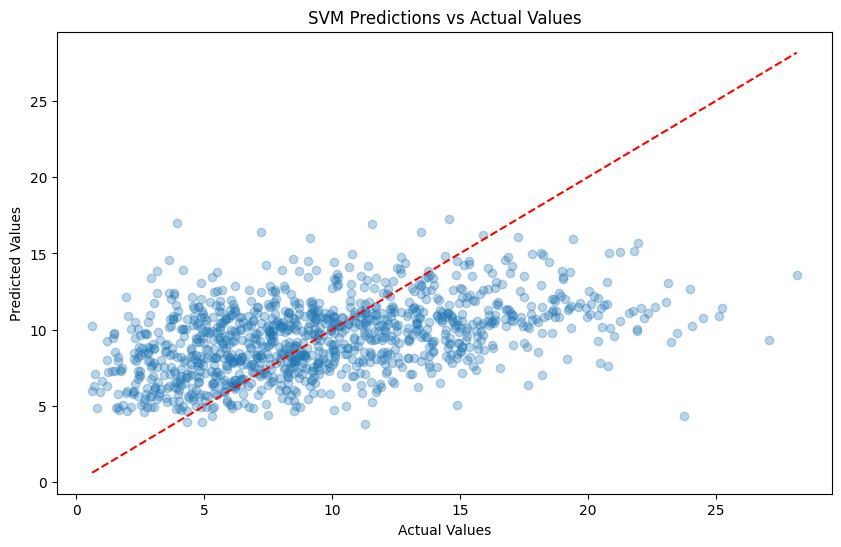

In [ ]:
import numpy as np
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Function to calculate Root Mean Squared Error (RMSE)
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Define the bisection-like optimization function for RMSE
def optimize_svm_hyperparameters(X_train, y_train, X_val, y_val, tol=1e-2, max_iter=20):
    # Initial parameter ranges
    C_left, C_right = 0.1, 1000
    gamma_left, gamma_right = 0.0001, 1

    best_C, best_gamma = C_left, gamma_left
    best_rmse = float('inf')

    for _ in range(max_iter):
        C_mid = (C_left + C_right) / 2
        gamma_mid = (gamma_left + gamma_right) / 2

        # Train SVR with mid values
        svr = SVR(C=C_mid, gamma=gamma_mid, kernel='rbf')
        svr.fit(X_train, y_train)
        y_pred = svr.predict(X_val)
        rmse = root_mean_squared_error(y_val, y_pred)

        print(f"Evaluating C={C_mid}, gamma={gamma_mid}, RMSE={rmse}")

        if rmse < best_rmse:
            best_rmse = rmse
            best_C, best_gamma = C_mid, gamma_mid

        # Narrow down the search space for C
        svr_left_C = SVR(C=C_left, gamma=gamma_mid, kernel='rbf')
        svr_left_C.fit(X_train, y_train)
        rmse_left_C = root_mean_squared_error(y_val, svr_left_C.predict(X_val))

        svr_right_C = SVR(C=C_right, gamma=gamma_mid, kernel='rbf')
        svr_right_C.fit(X_train, y_train)
        rmse_right_C = root_mean_squared_error(y_val, svr_right_C.predict(X_val))

        if rmse_left_C < rmse_right_C:
            C_right = C_mid
        else:
            C_left = C_mid

        # Narrow down the search space for gamma
        svr_left_gamma = SVR(C=C_mid, gamma=gamma_left, kernel='rbf')
        svr_left_gamma.fit(X_train, y_train)
        rmse_left_gamma = root_mean_squared_error(y_val, svr_left_gamma.predict(X_val))

        svr_right_gamma = SVR(C=C_mid, gamma=gamma_right, kernel='rbf')
        svr_right_gamma.fit(X_train, y_train)
        rmse_right_gamma = root_mean_squared_error(y_val, svr_right_gamma.predict(X_val))

        if rmse_left_gamma < rmse_right_gamma:
            gamma_right = gamma_mid
        else:
            gamma_left = gamma_mid

        # Check if the interval is sufficiently small
        if (C_right - C_left < tol) and (gamma_right - gamma_left < tol):
            break

    return best_C, best_gamma, best_rmse

# Perform the optimization
best_C, best_gamma, best_rmse = optimize_svm_hyperparameters(X_train, y_train, X_val, y_val)

print(f"Optimized C: {best_C}, gamma: {best_gamma}, RMSE: {best_rmse}")

# Train the final model with the best parameters
best_svr = SVR(C=best_C, gamma=best_gamma, kernel='rbf')
best_svr.fit(X_train, y_train)

# Make predictions on the validation set
y_pred = best_svr.predict(X_val)

# Calculate the RMSE on validation set
final_rmse = root_mean_squared_error(y_val, y_pred)
print(f'Final Root Mean Squared Error (RMSE): {final_rmse}')

# Plot the predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_pred, alpha=0.3)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('SVM Predictions vs Actual Values')
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linestyle='--')
plt.show()


Root Mean Squared Error (RMSE): 4.601543168370728


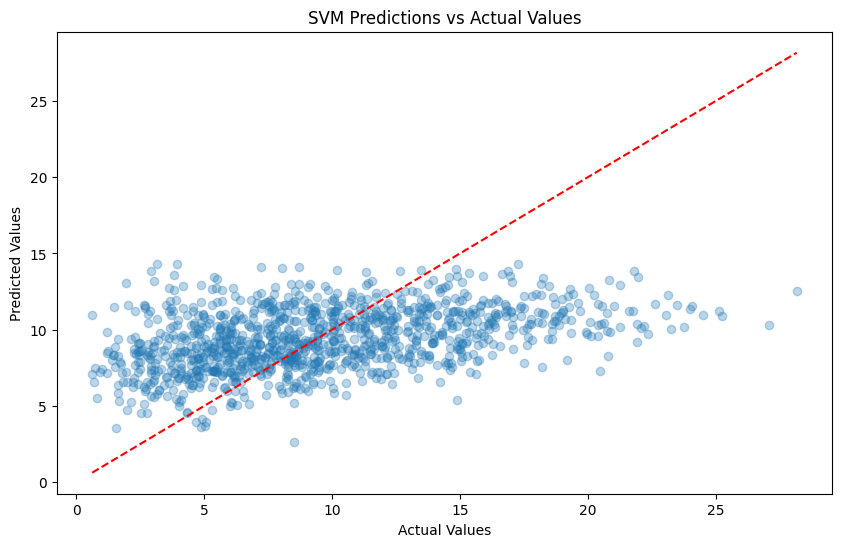

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate Root Mean Squared Error (RMSE)
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Create and train the SVM model with default parameters or manually chosen parameters
svm_model = SVR(C=1.0, gamma='scale', kernel='rbf')  # Example with default values
svm_model.fit(X_train, y_train)

# Predict on the validation set
y_pred = svm_model.predict(X_val)

# Calculate evaluation metrics (RMSE)
rmse = root_mean_squared_error(y_val, y_pred)
print(f'Root Mean Squared Error (RMSE): {rmse}')

# Plot the predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_pred, alpha=0.3)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('SVM Predictions vs Actual Values')
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linestyle='--')
plt.show()


# GBM

Evaluating learning_rate=0.505, n_estimators=525, max_depth=6, RMSE=5.312366544220232
Evaluating learning_rate=0.2575, n_estimators=287, max_depth=4, RMSE=4.7323513738708956
Evaluating learning_rate=0.13375, n_estimators=168, max_depth=3, RMSE=4.454396441424826
Evaluating learning_rate=0.195625, n_estimators=109, max_depth=3, RMSE=4.467342572961931
Evaluating learning_rate=0.1646875, n_estimators=138, max_depth=3, RMSE=4.451968879331666
Evaluating learning_rate=0.14921875, n_estimators=123, max_depth=3, RMSE=4.450803537442728
Evaluating learning_rate=0.156953125, n_estimators=116, max_depth=3, RMSE=4.442659361966835
Evaluating learning_rate=0.1530859375, n_estimators=119, max_depth=3, RMSE=4.440357492768652
Evaluating learning_rate=0.15501953125, n_estimators=121, max_depth=3, RMSE=4.453943316220201
Evaluating learning_rate=0.154052734375, n_estimators=120, max_depth=3, RMSE=4.446568702655568
Evaluating learning_rate=0.1535693359375, n_estimators=120, max_depth=3, RMSE=4.45348003647019

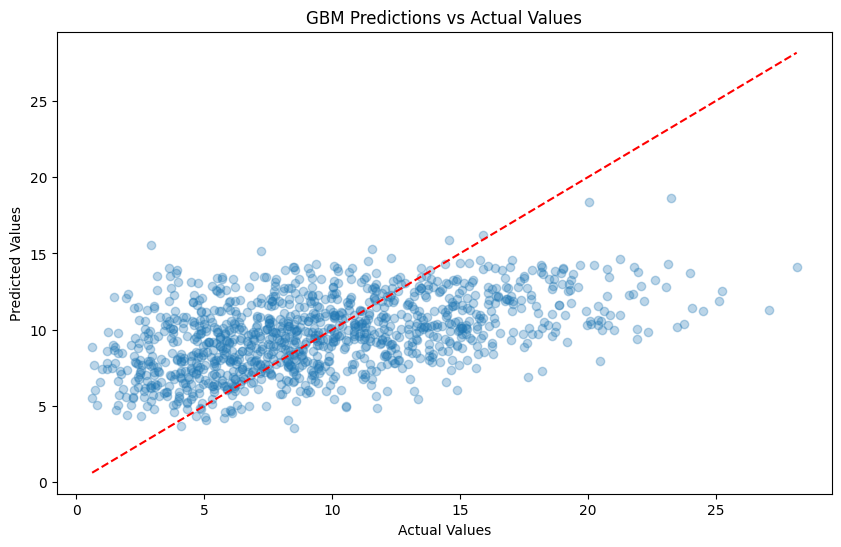

In [ ]:
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Function to calculate Root Mean Squared Error (RMSE)
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Contoh data X_train, X_val, y_train, y_val
# Pastikan data Anda telah dipisahkan dan siap untuk digunakan
def optimize_gbm_hyperparameters(X_train, y_train, X_val, y_val, tol=1e-2, max_iter=20):
    # Initial parameter ranges
    learning_rate_left, learning_rate_right = 0.01, 1.0
    n_estimators_left, n_estimators_right = 50, 1000
    max_depth_left, max_depth_right = 3, 10

    best_learning_rate, best_n_estimators, best_max_depth = learning_rate_left, n_estimators_left, max_depth_left
    best_rmse = float('inf')

    for _ in range(max_iter):
        # Calculate mid values
        learning_rate_mid = (learning_rate_left + learning_rate_right) / 2
        n_estimators_mid = (n_estimators_left + n_estimators_right) // 2
        max_depth_mid = (max_depth_left + max_depth_right) // 2

        # Train GBM with mid values
        gbm = GradientBoostingRegressor(learning_rate=learning_rate_mid, n_estimators=n_estimators_mid,
                                        max_depth=max_depth_mid, random_state=0)
        gbm.fit(X_train, y_train)
        y_pred = gbm.predict(X_val)
        rmse = root_mean_squared_error(y_val, y_pred)

        print(f"Evaluating learning_rate={learning_rate_mid}, n_estimators={n_estimators_mid}, max_depth={max_depth_mid}, RMSE={rmse}")

        if rmse < best_rmse:
            best_rmse = rmse
            best_learning_rate, best_n_estimators, best_max_depth = learning_rate_mid, n_estimators_mid, max_depth_mid

        # Narrow down the search space for learning_rate
        gbm_left_learning_rate = GradientBoostingRegressor(learning_rate=learning_rate_left, n_estimators=best_n_estimators,
                                                           max_depth=best_max_depth, random_state=0)
        gbm_left_learning_rate.fit(X_train, y_train)
        rmse_left_learning_rate = root_mean_squared_error(y_val, gbm_left_learning_rate.predict(X_val))

        gbm_right_learning_rate = GradientBoostingRegressor(learning_rate=learning_rate_right, n_estimators=best_n_estimators,
                                                            max_depth=best_max_depth, random_state=0)
        gbm_right_learning_rate.fit(X_train, y_train)
        rmse_right_learning_rate = root_mean_squared_error(y_val, gbm_right_learning_rate.predict(X_val))

        if rmse_left_learning_rate < rmse_right_learning_rate:
            learning_rate_right = learning_rate_mid
        else:
            learning_rate_left = learning_rate_mid

        # Narrow down the search space for n_estimators
        gbm_left_n_estimators = GradientBoostingRegressor(learning_rate=best_learning_rate, n_estimators=n_estimators_left,
                                                           max_depth=best_max_depth, random_state=0)
        gbm_left_n_estimators.fit(X_train, y_train)
        rmse_left_n_estimators = root_mean_squared_error(y_val, gbm_left_n_estimators.predict(X_val))

        gbm_right_n_estimators = GradientBoostingRegressor(learning_rate=best_learning_rate, n_estimators=n_estimators_right,
                                                            max_depth=best_max_depth, random_state=0)
        gbm_right_n_estimators.fit(X_train, y_train)
        rmse_right_n_estimators = root_mean_squared_error(y_val, gbm_right_n_estimators.predict(X_val))

        if rmse_left_n_estimators < rmse_right_n_estimators:
            n_estimators_right = n_estimators_mid
        else:
            n_estimators_left = n_estimators_mid

        # Narrow down the search space for max_depth
        gbm_left_max_depth = GradientBoostingRegressor(learning_rate=best_learning_rate, n_estimators=best_n_estimators,
                                                       max_depth=max_depth_left, random_state=0)
        gbm_left_max_depth.fit(X_train, y_train)
        rmse_left_max_depth = root_mean_squared_error(y_val, gbm_left_max_depth.predict(X_val))

        gbm_right_max_depth = GradientBoostingRegressor(learning_rate=best_learning_rate, n_estimators=best_n_estimators,
                                                        max_depth=max_depth_right, random_state=0)
        gbm_right_max_depth.fit(X_train, y_train)
        rmse_right_max_depth = root_mean_squared_error(y_val, gbm_right_max_depth.predict(X_val))

        if rmse_left_max_depth < rmse_right_max_depth:
            max_depth_right = max_depth_mid
        else:
            max_depth_left = max_depth_mid

        # Check if the interval is sufficiently small
        if (learning_rate_right - learning_rate_left < tol) and \
           (n_estimators_right - n_estimators_left < tol) and \
           (max_depth_right - max_depth_left < tol):
            break

    return best_learning_rate, best_n_estimators, best_max_depth, best_rmse

# Perform the optimization
best_learning_rate, best_n_estimators, best_max_depth, best_rmse = optimize_gbm_hyperparameters(X_train, y_train, X_val, y_val)

print(f"Optimized learning_rate: {best_learning_rate}, n_estimators: {best_n_estimators}, max_depth: {best_max_depth}, RMSE: {best_rmse}")

# Train the final model with the best parameters
best_gbm = GradientBoostingRegressor(learning_rate=best_learning_rate, n_estimators=best_n_estimators,
                                     max_depth=best_max_depth, random_state=0)
best_gbm.fit(X_train, y_train)

# Make predictions on the validation set
y_pred = best_gbm.predict(X_val)

# Calculate the Root Mean Squared Error (RMSE)
final_rmse = root_mean_squared_error(y_val, y_pred)
print(f'Final Root Mean Squared Error (RMSE): {final_rmse}')

# Plot the predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_pred, alpha=0.3)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('GBM Predictions vs Actual Values')
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linestyle='--')
plt.show()


Root Mean Squared Error (RMSE): 4.449546876281725


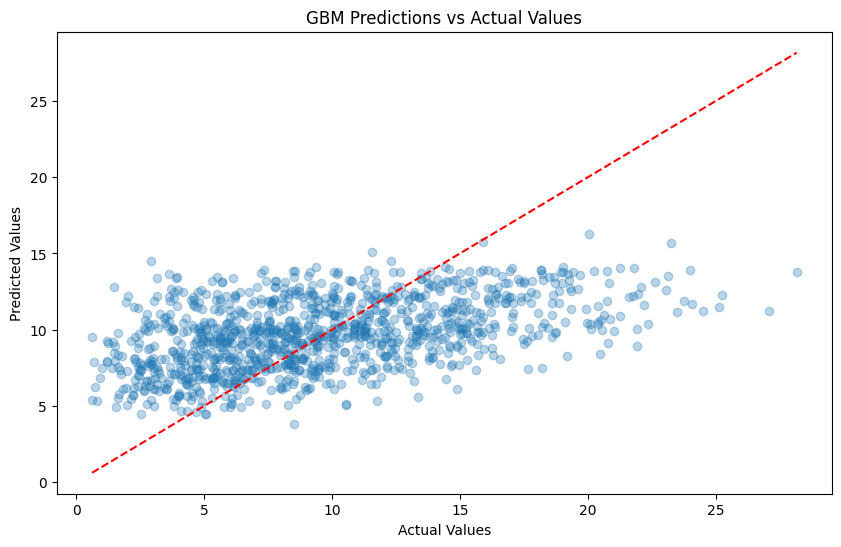

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# Function to calculate Root Mean Squared Error (RMSE)
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Create and train the GBM model with default parameters or manually chosen parameters
gbm_model = GradientBoostingRegressor(learning_rate=0.1, n_estimators=100, max_depth=3, random_state=42)  # Example with default values
gbm_model.fit(X_train, y_train)

# Predict on the validation set
y_pred = gbm_model.predict(X_val)

# Calculate evaluation metrics (RMSE)
rmse = root_mean_squared_error(y_val, y_pred)
print(f'Root Mean Squared Error (RMSE): {rmse}')

# Plot the predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_pred, alpha=0.3)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('GBM Predictions vs Actual Values')
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linestyle='--')
plt.show()


#logreg

Evaluating n_neighbors=25, RMSE=4.569223453104167
Evaluating n_neighbors=37, RMSE=4.5422525817272
Evaluating n_neighbors=43, RMSE=4.531517649880867
Evaluating n_neighbors=46, RMSE=4.5267012960668715
Evaluating n_neighbors=48, RMSE=4.524501673046593
Evaluating n_neighbors=49, RMSE=4.523909492149305
Evaluating n_neighbors=49, RMSE=4.523909492149305
Evaluating n_neighbors=49, RMSE=4.523909492149305
Evaluating n_neighbors=49, RMSE=4.523909492149305
Evaluating n_neighbors=49, RMSE=4.523909492149305
Evaluating n_neighbors=49, RMSE=4.523909492149305
Evaluating n_neighbors=49, RMSE=4.523909492149305
Evaluating n_neighbors=49, RMSE=4.523909492149305
Evaluating n_neighbors=49, RMSE=4.523909492149305
Evaluating n_neighbors=49, RMSE=4.523909492149305
Evaluating n_neighbors=49, RMSE=4.523909492149305
Evaluating n_neighbors=49, RMSE=4.523909492149305
Evaluating n_neighbors=49, RMSE=4.523909492149305
Evaluating n_neighbors=49, RMSE=4.523909492149305
Evaluating n_neighbors=49, RMSE=4.523909492149305
O

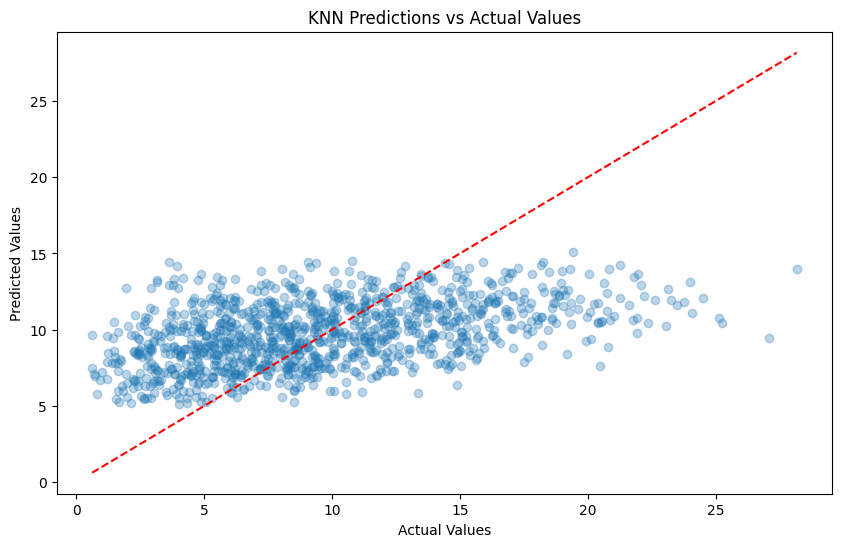

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Function to calculate Root Mean Squared Error (RMSE)
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Define the bisection-like optimization function for RMSE
def optimize_knn_hyperparameters(X_train, y_train, X_val, y_val, tol=1, max_iter=20):
    # Initial parameter range
    n_left, n_right = 1, 50

    best_n_neighbors = n_left
    best_rmse = float('inf')

    for _ in range(max_iter):
        n_mid = (n_left + n_right) // 2

        # Train KNN with mid value of n_neighbors
        knn = KNeighborsRegressor(n_neighbors=n_mid)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_val)
        rmse = root_mean_squared_error(y_val, y_pred)

        print(f"Evaluating n_neighbors={n_mid}, RMSE={rmse}")

        if rmse < best_rmse:
            best_rmse = rmse
            best_n_neighbors = n_mid

        # Narrow down the search space for n_neighbors
        knn_left_n = KNeighborsRegressor(n_neighbors=n_left)
        knn_left_n.fit(X_train, y_train)
        rmse_left_n = root_mean_squared_error(y_val, knn_left_n.predict(X_val))

        knn_right_n = KNeighborsRegressor(n_neighbors=n_right)
        knn_right_n.fit(X_train, y_train)
        rmse_right_n = root_mean_squared_error(y_val, knn_right_n.predict(X_val))

        if rmse_left_n < rmse_right_n:
            n_right = n_mid
        else:
            n_left = n_mid

        # Check if the interval is sufficiently small
        if (n_right - n_left < tol):
            break

    return best_n_neighbors, best_rmse


# Perform the optimization
best_n_neighbors, best_rmse = optimize_knn_hyperparameters(X_train, y_train, X_val, y_val)

print(f"Optimized n_neighbors: {best_n_neighbors}, RMSE: {best_rmse}")

# Train the final model with the best parameters
best_knn = KNeighborsRegressor(n_neighbors=best_n_neighbors)
best_knn.fit(X_train, y_train)

# Make predictions on the validation set
y_pred = best_knn.predict(X_val)

# Calculate the Root Mean Squared Error (RMSE)
final_rmse = root_mean_squared_error(y_val, y_pred)
print(f'Final Root Mean Squared Error (RMSE): {final_rmse}')

# Plot the predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_pred, alpha=0.3)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('KNN Predictions vs Actual Values')
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linestyle='--')
plt.show()


Root Mean Squared Error (RMSE): 4.8233331909502155


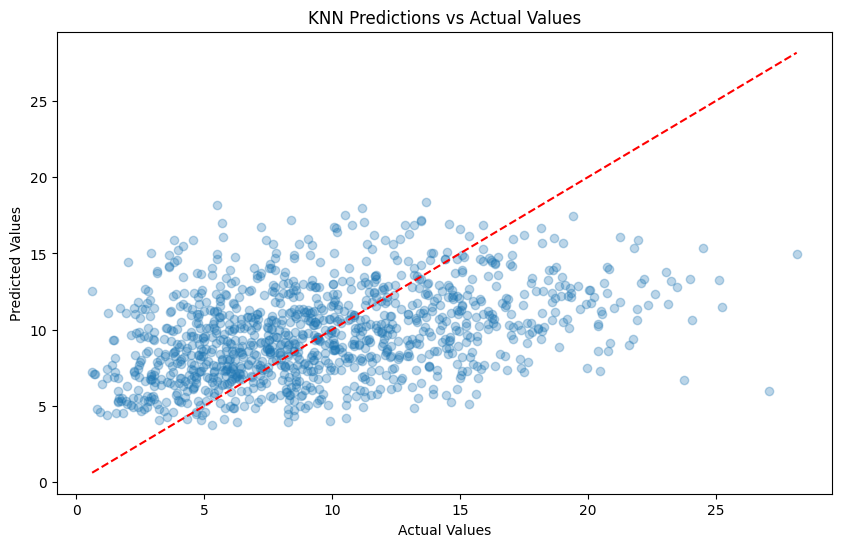

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Function to calculate Root Mean Squared Error (RMSE)
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Train the KNN model (example with n_neighbors=5)
n_neighbors = 5
knn = KNeighborsRegressor(n_neighbors=n_neighbors)
knn.fit(X_train, y_train)

# Make predictions on the validation set
y_pred = knn.predict(X_val)

# Calculate the Root Mean Squared Error (RMSE)
rmse = root_mean_squared_error(y_val, y_pred)
print(f'Root Mean Squared Error (RMSE): {rmse}')

# Plot the predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_pred, alpha=0.3)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('KNN Predictions vs Actual Values')
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linestyle='--')
plt.show()


# random forest

Evaluating n_estimators=105, max_depth=11, RMSE=4.501609644625009
Evaluating n_estimators=152, max_depth=15, RMSE=4.561368576643299
Evaluating n_estimators=176, max_depth=13, RMSE=4.522530606500144
Evaluating n_estimators=188, max_depth=12, RMSE=4.5116394130763515
Evaluating n_estimators=182, max_depth=11, RMSE=4.490453882466213
Evaluating n_estimators=179, max_depth=11, RMSE=4.487399876782048
Evaluating n_estimators=177, max_depth=11, RMSE=4.487071580163378
Evaluating n_estimators=176, max_depth=11, RMSE=4.486813729116883
Optimized Hyperparameters: n_estimators = 176, max_depth = 11, Best RMSE = 4.486813729116883
Final Root Mean Squared Error (RMSE): 4.486813729116883


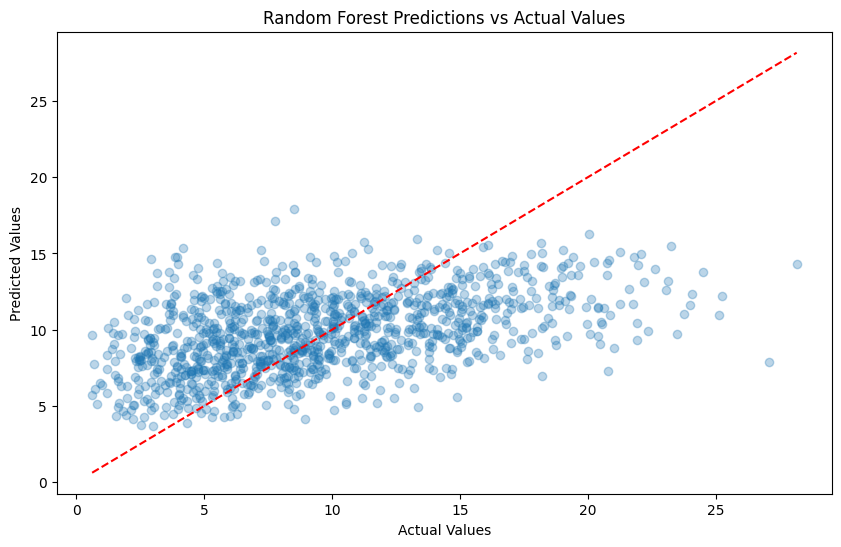

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Function to calculate Root Mean Squared Error (RMSE)
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Define the bisection-like optimization function for RMSE
def optimize_random_forest_hyperparameters(X_train, y_train, X_val, y_val, tol=1e-2, max_iter=20):
    # Initial parameter ranges
    n_estimators_left, n_estimators_right = 10, 200
    max_depth_left, max_depth_right = 2, 20

    best_n_estimators = n_estimators_left
    best_max_depth = max_depth_left
    best_rmse = float('inf')

    for _ in range(max_iter):
        n_estimators_mid = (n_estimators_left + n_estimators_right) // 2
        max_depth_mid = (max_depth_left + max_depth_right) // 2

        # Train Random Forest with mid values
        rf = RandomForestRegressor(n_estimators=n_estimators_mid, max_depth=max_depth_mid, random_state=0)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_val)
        rmse = root_mean_squared_error(y_val, y_pred)

        print(f"Evaluating n_estimators={n_estimators_mid}, max_depth={max_depth_mid}, RMSE={rmse}")

        if rmse < best_rmse:
            best_rmse = rmse
            best_n_estimators = n_estimators_mid
            best_max_depth = max_depth_mid

        # Narrow down the search space for n_estimators
        rf_left_n_estimators = RandomForestRegressor(n_estimators=n_estimators_left, max_depth=max_depth_mid, random_state=0)
        rf_left_n_estimators.fit(X_train, y_train)
        rmse_left_n_estimators = root_mean_squared_error(y_val, rf_left_n_estimators.predict(X_val))

        rf_right_n_estimators = RandomForestRegressor(n_estimators=n_estimators_right, max_depth=max_depth_mid, random_state=0)
        rf_right_n_estimators.fit(X_train, y_train)
        rmse_right_n_estimators = root_mean_squared_error(y_val, rf_right_n_estimators.predict(X_val))

        if rmse_left_n_estimators < rmse_right_n_estimators:
            n_estimators_right = n_estimators_mid
        else:
            n_estimators_left = n_estimators_mid

        # Narrow down the search space for max_depth
        rf_left_max_depth = RandomForestRegressor(n_estimators=n_estimators_mid, max_depth=max_depth_left, random_state=0)
        rf_left_max_depth.fit(X_train, y_train)
        rmse_left_max_depth = root_mean_squared_error(y_val, rf_left_max_depth.predict(X_val))

        rf_right_max_depth = RandomForestRegressor(n_estimators=n_estimators_mid, max_depth=max_depth_right, random_state=0)
        rf_right_max_depth.fit(X_train, y_train)
        rmse_right_max_depth = root_mean_squared_error(y_val, rf_right_max_depth.predict(X_val))

        if rmse_left_max_depth < rmse_right_max_depth:
            max_depth_right = max_depth_mid
        else:
            max_depth_left = max_depth_mid

        # Check if the interval is sufficiently small
        if (n_estimators_right - n_estimators_left < tol) and (max_depth_right - max_depth_left < tol):
            break

    return best_n_estimators, best_max_depth, best_rmse

# Assume X_train, X_val, y_train, y_val are already defined and split
# Perform the optimization
best_n_estimators, best_max_depth, best_rmse = optimize_random_forest_hyperparameters(X_train, y_train, X_val, y_val)

print(f"Optimized Hyperparameters: n_estimators = {best_n_estimators}, max_depth = {best_max_depth}, Best RMSE = {best_rmse}")

# Train the final model with the best parameters
best_rf = RandomForestRegressor(n_estimators=best_n_estimators, max_depth=best_max_depth, random_state=0)
best_rf.fit(X_train, y_train)

# Make predictions on the validation set
y_pred = best_rf.predict(X_val)

# Calculate the Root Mean Squared Error (RMSE)
final_rmse = root_mean_squared_error(y_val, y_pred)
print(f'Final Root Mean Squared Error (RMSE): {final_rmse}')

# Plot the predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_pred, alpha=0.3)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Random Forest Predictions vs Actual Values')
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linestyle='--')
plt.show()


Root Mean Squared Error (RMSE) with default Random Forest: 4.60


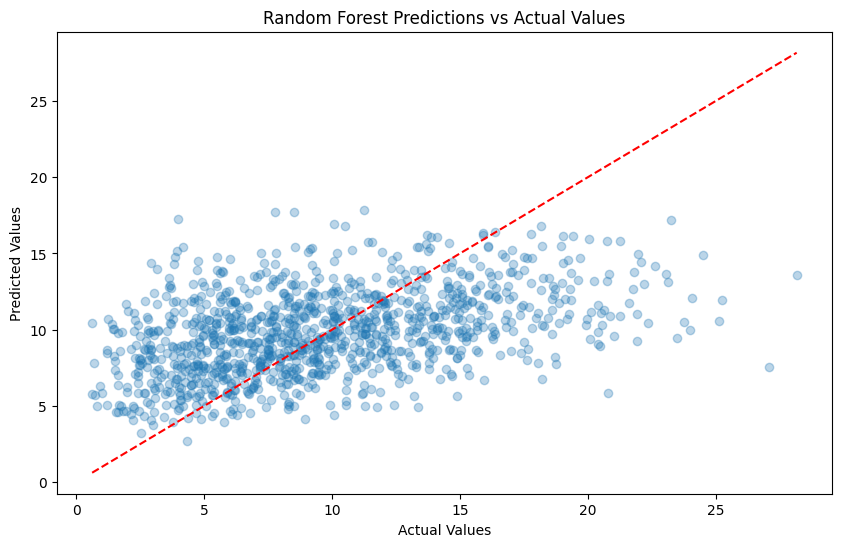

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Function to calculate Root Mean Squared Error (RMSE)
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Split data into train and validation sets (assuming X and y are defined)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Random Forest Regressor with default parameters
rf = RandomForestRegressor(random_state=0)

# Train the model
rf.fit(X_train, y_train)

# Make predictions on the validation set
y_pred = rf.predict(X_val)

# Calculate the Root Mean Squared Error (RMSE)
rmse = root_mean_squared_error(y_val, y_pred)
print(f'Root Mean Squared Error (RMSE) with default Random Forest: {rmse:.2f}')

# Plot the predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_pred, alpha=0.3)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Random Forest Predictions vs Actual Values')
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linestyle='--')
plt.show()
